In [8]:
import requests
import numpy as np
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urlencode
from concurrent.futures import ThreadPoolExecutor, as_completed
from pyrate_limiter import Duration, Rate, Limiter

In [2]:
# =========================================================
# Scraper function
# =========================================================
def scrape_bing_news_html(query: str, ticker: str, template: str, freshness: str = "Day"):
    base_url = "https://www.bing.com/news/search"

    params = {
        "q": query,
        "form": "HDRSC6",
        "qft": f'interval="{freshness}"'
    }

    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    url = f"{base_url}?{urlencode(params)}"

    try:
        limiter.try_acquire("bing_news")
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()

        soup = BeautifulSoup(response.text, "html.parser")

        records = []

        # Bing markup can change, so these selectors may need updating
        cards = soup.select("div.news-card, div.t_s, div.newsitem, div.card-common")

        for card in cards:
            title = None
            link = None
            source = None
            snippet = None
            time_text = None
            image_url = None

            a = card.select_one("a.title") or card.select_one("a")
            if a:
                title = a.get_text(" ", strip=True)
                link = a.get("href")

            source_el = (
                card.select_one(".source")
                or card.select_one(".provider")
                or card.select_one("div.source")
                or card.select_one("span.source")
            )
            if source_el:
                source = source_el.get_text(" ", strip=True)

            snippet_el = (
                card.select_one(".snippet")
                or card.select_one(".caption")
                or card.select_one("div.snippet")
                or card.select_one("div.caption")
                or card.select_one("p")
            )
            if snippet_el:
                snippet = snippet_el.get_text(" ", strip=True)

            time_el = (
                card.select_one("span.time")
                or card.select_one(".time")
                or card.select_one("span")
            )
            if time_el:
                time_text = time_el.get_text(" ", strip=True)

            img_el = card.select_one("img")
            if img_el:
                image_url = img_el.get("src") or img_el.get("data-src")

            if title or link:
                records.append({
                    "ticker": ticker,
                    "template": template,
                    "query": query,
                    "freshness": freshness,
                    "search_url": url,
                    "title": title,
                    "url": link,
                    "source": source,
                    "snippet": snippet,
                    "time_text": time_text,
                    "image_url": image_url
                })

        return records

    except Exception as e:
        return [{
            "ticker": ticker,
            "template": template,
            "query": query,
            "freshness": freshness,
            "search_url": url,
            "title": None,
            "url": None,
            "source": None,
            "snippet": None,
            "time_text": None,
            "image_url": None,
            "error": str(e),
            "n_results_for_query": 0
        }]

In [3]:
TICKERS = """
AAPL
MSFT
GOOGL
AMZN
META
TSLA
NVDA
JPM
UNH
MA
DIS
MSTR
""".strip().splitlines()

QUERY_TEMPLATES = """
stock
earnings
guidance
outlook
analyst upgrade
analyst downgrade
price target
dividend
inflation
forecast
sentiment
""".strip().splitlines()

FRESHNESS = "Day"   # often "Day", "Week", "Month"
MAX_RESULTS_PER_QUERY = 50
MAX_WORKERS = 5

limiter = Limiter(Rate(50, Duration.SECOND))

# =========================================================
# Build query list
# =========================================================
queries = []
for ticker in TICKERS:
    for template in QUERY_TEMPLATES:
        queries.append({
            "ticker": ticker,
            "template": template,
            "query": f"{ticker} {template}"
        })



# =========================================================
# Run all queries (parallel with rate limiting)
# =========================================================
all_records = []
query_stats = []

def _worker(row):
    ticker   = row["ticker"]
    template = row["template"]
    query    = row["query"]
    records  = scrape_bing_news_html(query=query, ticker=ticker, template=template, freshness=FRESHNESS)
    return ticker, template, query, records

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = {executor.submit(_worker, row): i for i, row in enumerate(queries)}

    for done, fut in enumerate(as_completed(futures), start=1):
        ticker, template, query, records = fut.result()
        print(f"[{done}/{len(queries)}] {ticker} | {template}  ({len(records)} results)")

        n = len(records)
        has_error = n == 1 and records[0].get("error")

        if n == 0 or has_error:
            all_records.append({
                "ticker": ticker,
                "template": template,
                "query": query,
                "freshness": FRESHNESS,
                "search_url": None,
                "title": None,
                "url": None,
                "source": None,
                "snippet": None,
                "time_text": None,
                "image_url": None,
                "error": records[0].get("error") if records else None,
                "n_results_for_query": 0
            })
            query_stats.append({
                "ticker": ticker,
                "template": template,
                "query": query,
                "n_results": 0,
                "error": records[0].get("error") if records else None
            })
        else:
            for r in records[:MAX_RESULTS_PER_QUERY]:
                r["error"] = None
                r["n_results_for_query"] = n
                all_records.append(r)
            query_stats.append({
                "ticker": ticker,
                "template": template,
                "query": query,
                "n_results": n,
                "error": None
            })

[1/132] AAPL | analyst upgrade  (4 results)
[2/132] AAPL | stock  (24 results)
[3/132] AAPL | earnings  (24 results)
[4/132] AAPL | guidance  (6 results)
[5/132] AAPL | outlook  (6 results)
[6/132] AAPL | analyst downgrade  (8 results)
[7/132] AAPL | dividend  (6 results)
[8/132] AAPL | price target  (22 results)
[9/132] AAPL | inflation  (2 results)
[10/132] AAPL | forecast  (4 results)
[11/132] AAPL | sentiment  (4 results)
[12/132] MSFT | guidance  (10 results)
[13/132] MSFT | stock  (24 results)
[14/132] MSFT | earnings  (24 results)
[15/132] MSFT | outlook  (4 results)
[16/132] MSFT | analyst upgrade  (0 results)
[17/132] MSFT | price target  (18 results)
[18/132] MSFT | analyst downgrade  (0 results)
[19/132] MSFT | inflation  (0 results)
[20/132] MSFT | dividend  (14 results)
[21/132] MSFT | forecast  (6 results)
[22/132] MSFT | sentiment  (4 results)
[23/132] GOOGL | stock  (24 results)
[24/132] GOOGL | guidance  (2 results)
[25/132] GOOGL | earnings  (22 results)
[26/132] GOOG

In [4]:
# =========================================================
# Build dataframes
# =========================================================
df = pd.DataFrame(all_records)
df_query_stats = pd.DataFrame(query_stats)

# Deduped by URL
df = (
    df.dropna(subset=["url"])
      .drop_duplicates(subset=["url"])
      .sort_values(by=["ticker", "template"])
      .reset_index(drop=True)
)

display(df)

,ticker,template,query,freshness,search_url,title,url,source,snippet,time_text,image_url,error,n_results_for_query
0,AAPL,analyst downgrade,AAPL analyst downgrade,Day,https://www.bing.com/news/search?q=AAPL+analys...,"SA analyst upgrades/downgrades: AAPL, SPOT, MU...",https://www.msn.com/en-us/money/topstocks/sa-a...,10d on MSN,Spotify (SPOT) received an upgrade to Buy from...,,/th?id=OJ.x77cVnOcZaJPEg&pid=news&w=81&h=16&rs=2,None,8
1,AAPL,analyst downgrade,AAPL analyst downgrade,Day,https://www.bing.com/news/search?q=AAPL+analys...,Apple Stock Starts 2026 With a Downgrade. Why ...,https://www.aol.com/articles/apple-stock-start...,AOL 3mon,"For Apple (NASDAQ:AAPL) shareholders, it feels...",,None,None,8
2,AAPL,analyst downgrade,AAPL analyst downgrade,Day,https://www.bing.com/news/search?q=AAPL+analys...,Apple Stock Starts 2026 With a Downgrade. Why ...,https://www.aol.com/finance/apple-stock-starts...,AOL 3mon,Apple shares dropped 7% from their December pe...,,None,None,8
3,AAPL,analyst upgrade,AAPL analyst upgrade,Day,https://www.bing.com/news/search?q=AAPL+analys...,"SA analyst upgrades/downgrades: TSLA, AAPL, AM...",https://www.msn.com/en-us/money/top-stocks/sa-...,4d on MSN,Recent analyst actions on Seeking Alpha have h...,,/th?id=ONUT.4kOgQNRyWSKAn0ciKNycBQ&pid=News&w=...,None,4
4,AAPL,analyst upgrade,AAPL analyst upgrade,Day,https://www.bing.com/news/search?q=AAPL+analys...,"SA analyst upgrades/downgrades: AAPL, SPOT, MU...",https://www.msn.com/en-us/money/topstocks/sa-a...,10d on MSN,Spotify (SPOT) received an upgrade to Buy from...,,/th?id=OJ.x77cVnOcZaJPEg&pid=news&w=81&h=16&rs=2,None,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
520,UNH,stock,UNH stock,Day,https://www.bing.com/news/search?q=UNH+stock&f...,Morgan Stanley adjusts UNH stock price target ...,https://www.msn.com/en-us/money/general/morgan...,8d on MSN,UnitedHealth stock just got a price upgrade fr...,,/th?id=ONUT.SEvuib3wkFseQaJ85tCehw&pid=News&w=...,None,22
521,UNH,stock,UNH stock,Day,https://www.bing.com/news/search?q=UNH+stock&f...,How UNH Stock Is Trading Short-Term Margins Fo...,https://finance.yahoo.com/markets/stocks/artic...,10d,The Q1 2026 data reveals a strategic decouplin...,,/th?id=ONUT.xsP0SfAQZ9Sr--0wDV4IUQ&pid=News&w=...,None,22
522,UNH,stock,UNH stock,Day,https://www.bing.com/news/search?q=UNH+stock&f...,UnitedHealth (UNH) Stock Soars 6% Following Bl...,https://blockonomi.com/unitedhealth-unh-stock-...,Blockonomi 11d,UnitedHealth (UNH) stock surges 5.7% after Q1 ...,,/th?id=ONUT.aUVfRYO-PvL9QzMJXQiNUg&pid=News&w=...,None,22
523,UNH,stock,UNH stock,Day,https://www.bing.com/news/search?q=UNH+stock&f...,How Bad Can It Get For UnitedHealth?,https://www.forbes.com/sites/greatspeculations...,Forbes 5mon,UnitedHealth (UNH) stock has decreased by 15.4...,,None,None,22


In [5]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

# Downloads ~500MB on first run, then cached at ~/.cache/huggingface/hub
MODEL = "ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)
model.eval()
print("Labels:", model.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


In [9]:
def get_sentiment(texts: list) -> pd.DataFrame:
    inputs = tokenizer(texts, padding=True, truncation=True, max_length=512, return_tensors="pt")
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = F.softmax(logits, dim=-1)
    labels = model.config.id2label
    rows = [
        {"text": t, **{labels[i]: round(p.item(), 4) for i, p in enumerate(prob)}}
        for t, prob in zip(texts, probs)
    ]
    df = pd.DataFrame(rows)
    label_cols = list(model.config.id2label.values())
    df["score"] = df.positive - df.negative
    df["prediction"] = df[label_cols].idxmax(axis=1)
    return df

titles = df["title"].fillna("").tolist()
df_sent = get_sentiment(titles)
df2 = pd.concat([df, df_sent], axis=1)

sent = (
    df2.groupby("ticker")
      .apply(lambda g: np.average(
          g["score"],
          #weights=g["weight"]
      ))
)
sent = sent.sort_values(ascending=False)
print(sent)

ticker
AAPL     0.237564
UNH      0.220371
GOOGL    0.189859
MSTR     0.170392
MA       0.157104
JPM      0.155010
NVDA     0.079057
TSLA     0.077126
AMZN     0.073391
MSFT     0.068977
DIS     -0.110542
META    -0.184235
dtype: float64


C:\Users\Graham West\AppData\Local\Temp\ipykernel_26612\991702379.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(


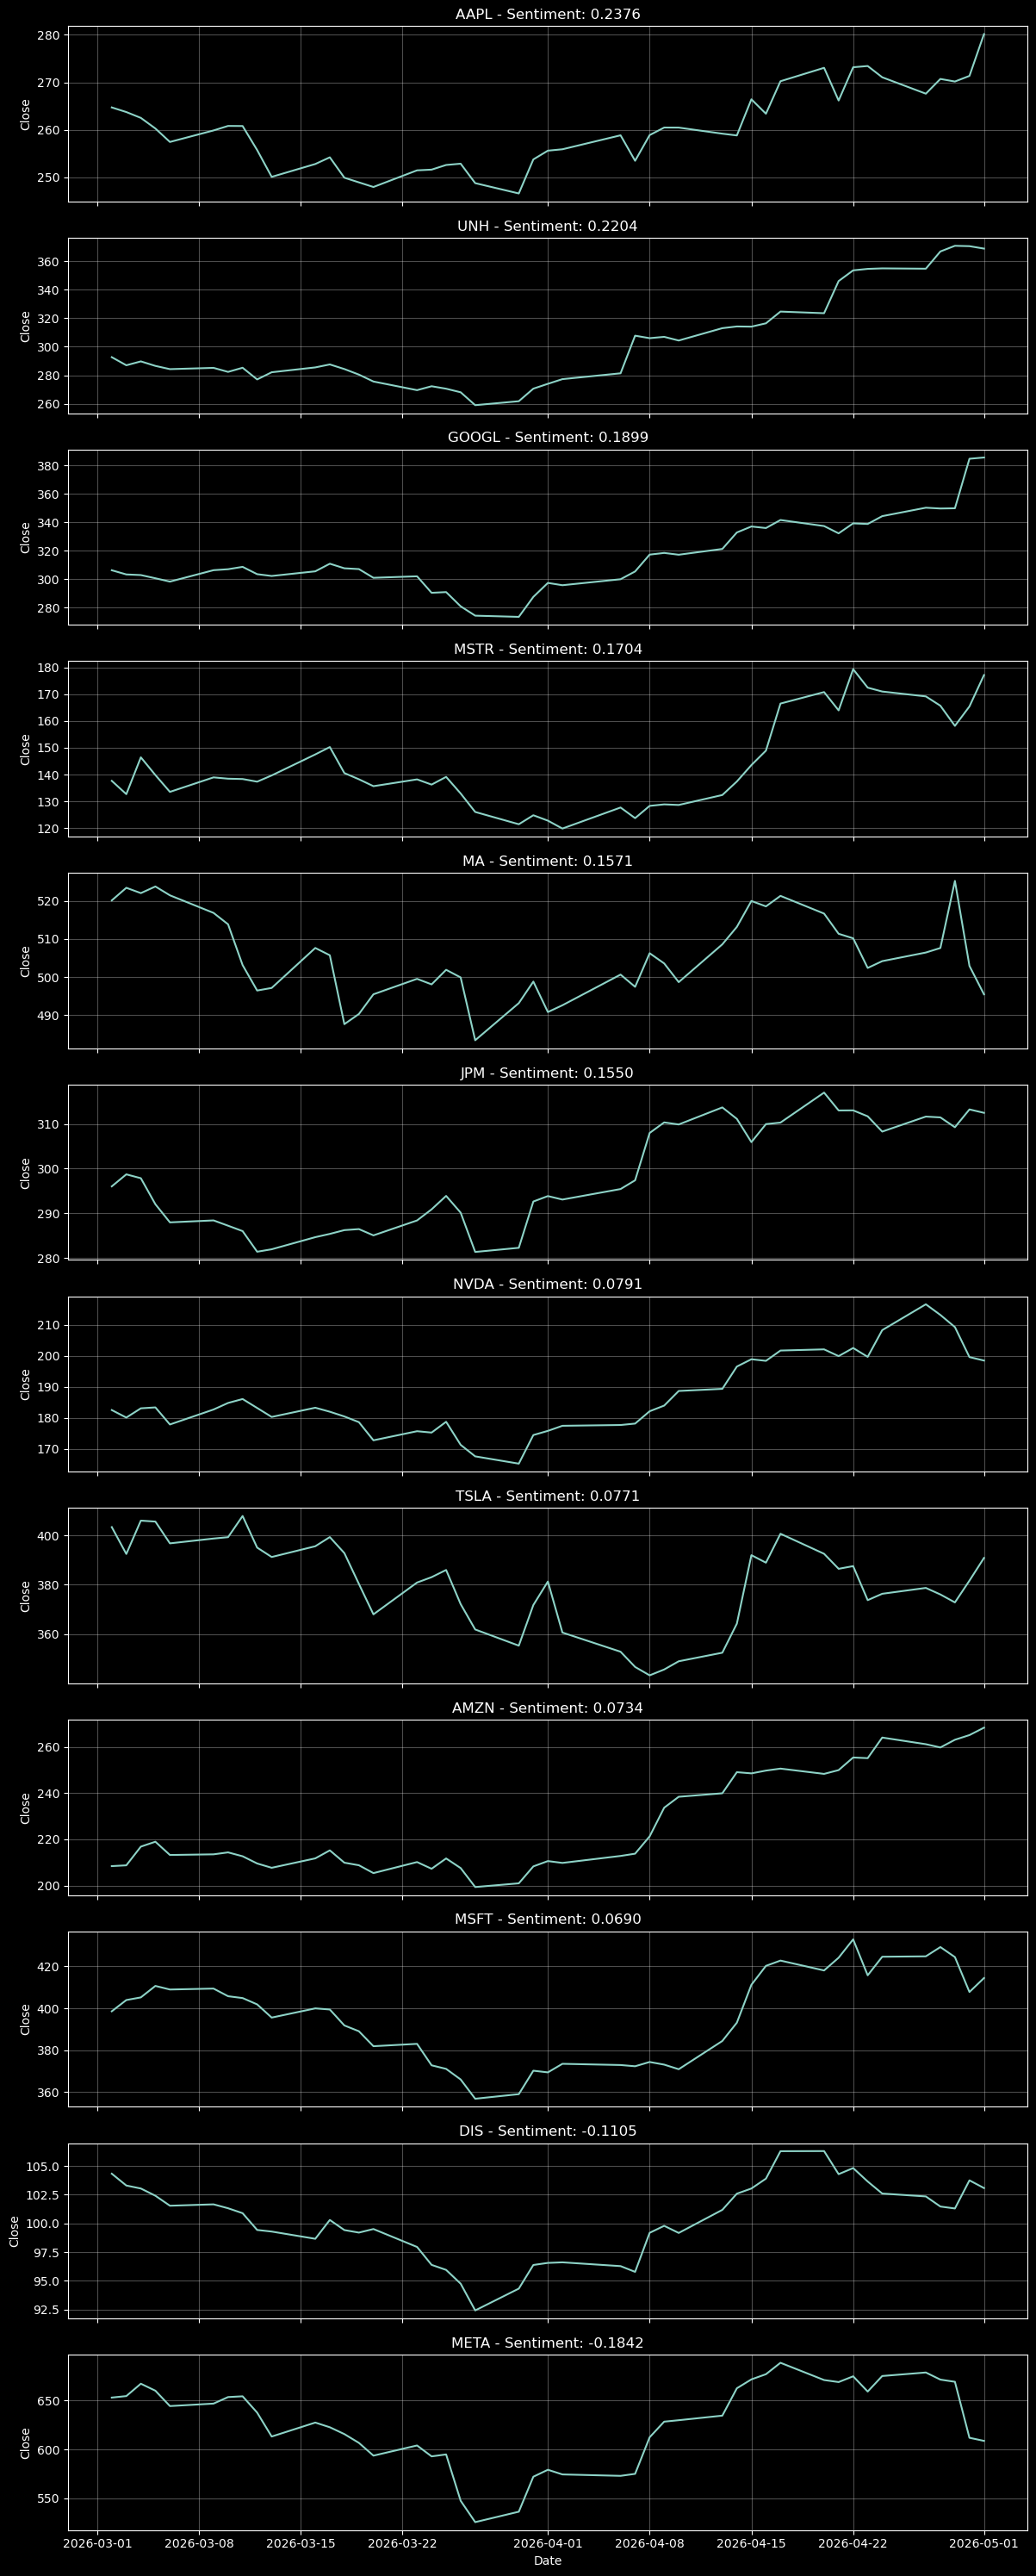

In [11]:
import yfinance as yf
import matplotlib.pyplot as plt
plt.style.use("dark_background")

START_DATE = "2026-03-01"

# --- Download data ---
df_yf = yf.download(
    TICKERS,
    start=START_DATE,
    interval="1d",
    group_by="ticker",
    auto_adjust=True,
    progress=False,
)

# --- Create subplots ---
n = len(TICKERS)

fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(12, 2.5 * n),
    sharex=True,
)

# If only one ticker, axes isn't a list
if n == 1:
    axes = [axes]

# --- Plot ---
for ax, ticker in zip(axes, sent.index):

    if ticker in df_yf.columns.get_level_values(0):
        close = df_yf[ticker]["Close"]

        ax.plot(close.index, close.values)

        ax.set_title(f"{ticker} - Sentiment: {sent.get(ticker, 0):.4f}")
        ax.set_ylabel("Close")

        ax.grid(True, alpha=0.3)

plt.xlabel("Date")
plt.tight_layout()

plt.show()